In [4]:
import os
import sys

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))

if project_root not in sys.path:
    sys.path.append(project_root)
print(f"Đã thêm vào path: {project_root}")

Đã thêm vào path: d:\Practical-Lesson\ds210-deep-learning\lesson-05


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn

from seqeval.metrics import f1_score, classification_report
from sklearn.metrics import confusion_matrix


from src.data_module2 import Vocabulary, PhoNERDataset, ner_collate_fn
from src.model02 import NERTransformer

from tqdm import tqdm


In [25]:
BATCH_SIZE = 32

In [32]:
D_MODEL = 256
NHEAD = 8
NUM_LAYERS = 3
MAX_LEN = 256
DROPOUT = 0.3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng: {device}")

Đang sử dụng: cuda


## 1. Preparation

In [19]:
_train = pd.read_json('../data/PhoNERT/train_word.json', lines=True)
_dev   = pd.read_json('../data/PhoNERT/dev_word.json', lines  =True)
_test  = pd.read_json('../data/PhoNERT/test_word.json', lines =True)

### 1.1. Vocabulary

In [17]:
word_vocab = Vocabulary(is_tag=False)
word_vocab.build_vocabulary(_train['words'])

tag_vocab = Vocabulary(is_tag=True)
tag_vocab.build_vocabulary(_train['tags'])

print(f"Từ điển từ: {len(word_vocab)}")
print(f"Từ điển nhãn: {len(tag_vocab)}")

Từ điển từ: 5243
Từ điển nhãn: 21


In [30]:
VOCAB_SIZE = len(word_vocab)
NUM_TAGS = len(tag_vocab)

### 1.2. Dataloader

#### 1.2.1. Dataset

In [21]:
train_dataset = PhoNERDataset(
    words_list=_train['words'].tolist(), 
    tags_list=_train['tags'].tolist(), 
    word_vocab=word_vocab, 
    tag_vocab=tag_vocab
)

In [22]:
val_dataset = PhoNERDataset(
    words_list=_dev['words'].tolist(), 
    tags_list=_dev['tags'].tolist(), 
    word_vocab=word_vocab, 
    tag_vocab=tag_vocab
)

In [24]:
test_dataset = PhoNERDataset(
    words_list=_test['words'].tolist(), 
    tags_list=_test['tags'].tolist(), 
    word_vocab=word_vocab, 
    tag_vocab=tag_vocab
)

#### 1.2.2. Dataloader

In [26]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=ner_collate_fn
)

In [27]:
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=ner_collate_fn
)

In [28]:
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=ner_collate_fn
)

In [29]:
inputs, targets, masks = next(iter(train_loader))

print(f"Input shape: {inputs.shape}")   # [batch_size, max_seq_len_in_batch]
print(f"Target shape: {targets.shape}") # [batch_size, max_seq_len_in_batch]
print(f"Mask shape: {masks.shape}")     # [batch_size, max_seq_len_in_batch]
print(f"Dữ liệu mẫu (input 0): {inputs[0]}")
print(f"Mask mẫu (mask 0): {masks[0]}")

Input shape: torch.Size([32, 56])
Target shape: torch.Size([32, 56])
Mask shape: torch.Size([32, 56])
Dữ liệu mẫu (input 0): tensor([325, 932,  12, 163,   3, 796,  43, 125, 126, 162, 127, 141,  28, 152,
        164, 206,  64, 122, 589,  12, 590,  12, 141,  19,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0])
Mask mẫu (mask 0): tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True])


### 1.3. Model

In [34]:
model = NERTransformer(
    vocab_size=VOCAB_SIZE,
    num_tags=NUM_TAGS,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    max_len=MAX_LEN
).to(device)
print(model)

NERTransformer(
  (embedding): Embedding(5243, 256)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=256, out_features=21, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


## 2. Training

### 2.1. Function

In [36]:
criterion = nn.CrossEntropyLoss(ignore_index=tag_vocab.pad_index)
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [ ]:
def evaluate(model, dataloader, criterion, tag_vocab, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, targets, masks in dataloader:
            inputs, targets, masks = inputs.to(device), targets.to(device), masks.to(device)
            
            logits = model(inputs, src_key_padding_mask=masks)
            loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
            total_loss += loss.item()
            
            preds = torch.argmax(logits, dim=-1)
            
            for i in range(targets.size(0)):
                y_true = []
                y_pred = []
                for j in range(targets.size(1)):
                    if targets[i][j] != tag_vocab.pad_index:
                        y_true.append(tag_vocab.itos[targets[i][j].item()])
                        y_pred.append(tag_vocab.itos[preds[i][j].item()])
                all_labels.append(y_true)
                all_preds.append(y_pred)
                
    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, f1

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for inputs, targets, masks in tqdm(dataloader, desc="Training", leave=False):
        inputs, targets, masks = inputs.to(device), targets.to(device), masks.to(device)
        
        optimizer.zero_grad()
        logits = model(inputs, src_key_padding_mask=masks)

        loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(dataloader)


In [ ]:
def train(model, train_loader, val_loader, criterion, optimizer, scheduler, tag_vocab, epochs, device):
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_f1': []
    }
    
    best_f1 = 0
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1 = evaluate(model, val_loader, criterion, tag_vocab, device)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), '../checkpoints/task02/best_ner_model.pth')
            print("=> Saved Best Model")
            
    return model, history

### 2.2. Training

In [47]:
epochs = 20

model, history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    tag_vocab=tag_vocab,
    epochs=epochs,
    device=device
)


Epoch 1/20


Train Loss: 0.3501 | Val Loss: 0.4136 | Val F1: 0.4765
=> Saved Best Model

Epoch 2/20


Train Loss: 0.2971 | Val Loss: 0.3688 | Val F1: 0.5227
=> Saved Best Model

Epoch 3/20


Train Loss: 0.2619 | Val Loss: 0.3471 | Val F1: 0.5506
=> Saved Best Model

Epoch 4/20


Train Loss: 0.2307 | Val Loss: 0.3354 | Val F1: 0.5825
=> Saved Best Model

Epoch 5/20


...

Train Loss: 0.1108 | Val Loss: 0.2866 | Val F1: 0.6608

Epoch 17/20


Train Loss: 0.1005 | Val Loss: 0.2838 | Val F1: 0.6718
=> Saved Best Model

Epoch 18/20


Train Loss: 0.0952 | Val Loss: 0.2966 | Val F1: 0.6698

Epoch 19/20


Train Loss: 0.0927 | Val Loss: 0.2964 | Val F1: 0.6758
=> Saved Best Model

Epoch 20/20


Train Loss: 0.0865 | Val Loss: 0.2940 | Val F1: 0.6723


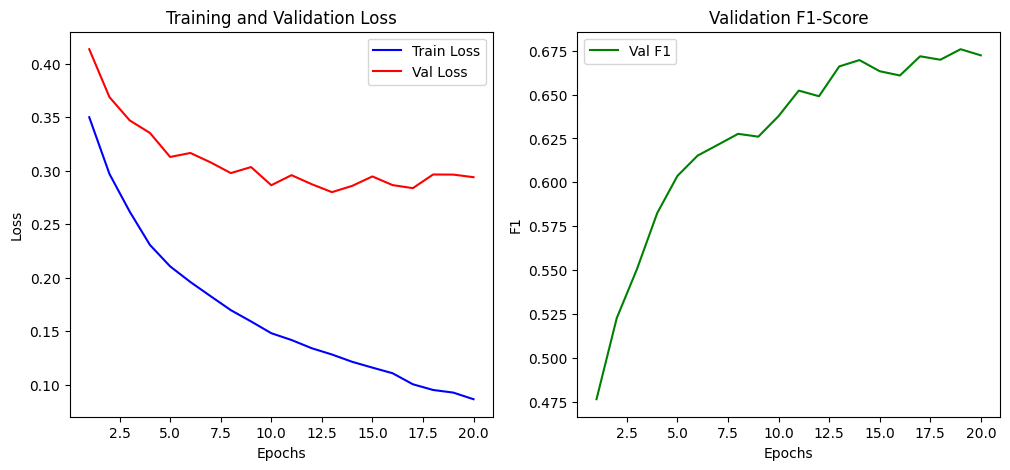

In [48]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_f1'], 'g-', label='Val F1')
    plt.title('Validation F1-Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1')
    plt.legend()
    
    plt.show()

plot_history(history)

## 3. Predicting

### 3.1. Get report

In [49]:
def get_detailed_report(model, dataloader, tag_vocab, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, targets, masks in dataloader:
            inputs, targets, masks = inputs.to(device), targets.to(device), masks.to(device)
            logits = model(inputs, src_key_padding_mask=masks)
            preds = torch.argmax(logits, dim=-1)
            
            for i in range(targets.size(0)):
                y_true = []
                y_pred = []
                for j in range(targets.size(1)):
                    if targets[i][j] != tag_vocab.pad_index:
                        y_true.append(tag_vocab.itos[targets[i][j].item()])
                        y_pred.append(tag_vocab.itos[preds[i][j].item()])
                all_labels.append(y_true)
                all_preds.append(y_pred)
    
    print("\n--- Detailed Classification Report ---")
    print(classification_report(all_labels, all_preds))
    return all_labels, all_preds

In [51]:
true_labels, pred_labels = get_detailed_report(model, test_loader, tag_vocab, device)


--- Detailed Classification Report ---
                     precision    recall  f1-score   support

                AGE       0.72      0.84      0.78       582
               DATE       0.56      0.80      0.66      1654
             GENDER       0.84      0.94      0.89       462
                JOB       0.36      0.50      0.42       173
           LOCATION       0.57      0.71      0.63      4441
               NAME       0.81      0.46      0.59       318
       ORGANIZATION       0.38      0.52      0.44       771
         PATIENT_ID       0.78      0.83      0.81      2005
SYMPTOM_AND_DISEASE       0.58      0.67      0.62      1136
     TRANSPORTATION       0.61      0.62      0.62       193

          micro avg       0.60      0.73      0.66     11735
          macro avg       0.62      0.69      0.64     11735
       weighted avg       0.62      0.73      0.66     11735



### 3.2. Analysis

In [59]:
def plot_confusion_matrix(all_labels, all_preds, tag_vocab):
    flat_true = [item for sublist in all_labels for item in sublist]
    flat_pred = [item for sublist in all_preds for item in sublist]

    labels = sorted(list(set(flat_true)))

    cm = confusion_matrix(flat_true, flat_pred, labels=labels)

    cm_ratio = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
    cm_percentage = cm_ratio * 100

    plt.figure(figsize=(14, 11))

    sns.heatmap(cm_percentage, annot=True, fmt='.1f', xticklabels=labels, yticklabels=labels, cmap='Blues')
    
    plt.xlabel('Predicted (%)')
    plt.ylabel('True (%)')
    plt.title('Confusion Matrix per Token (Percentage %)')
    plt.savefig('../img/task02_confusion_matrix_per_token.png')
    
    plt.show()

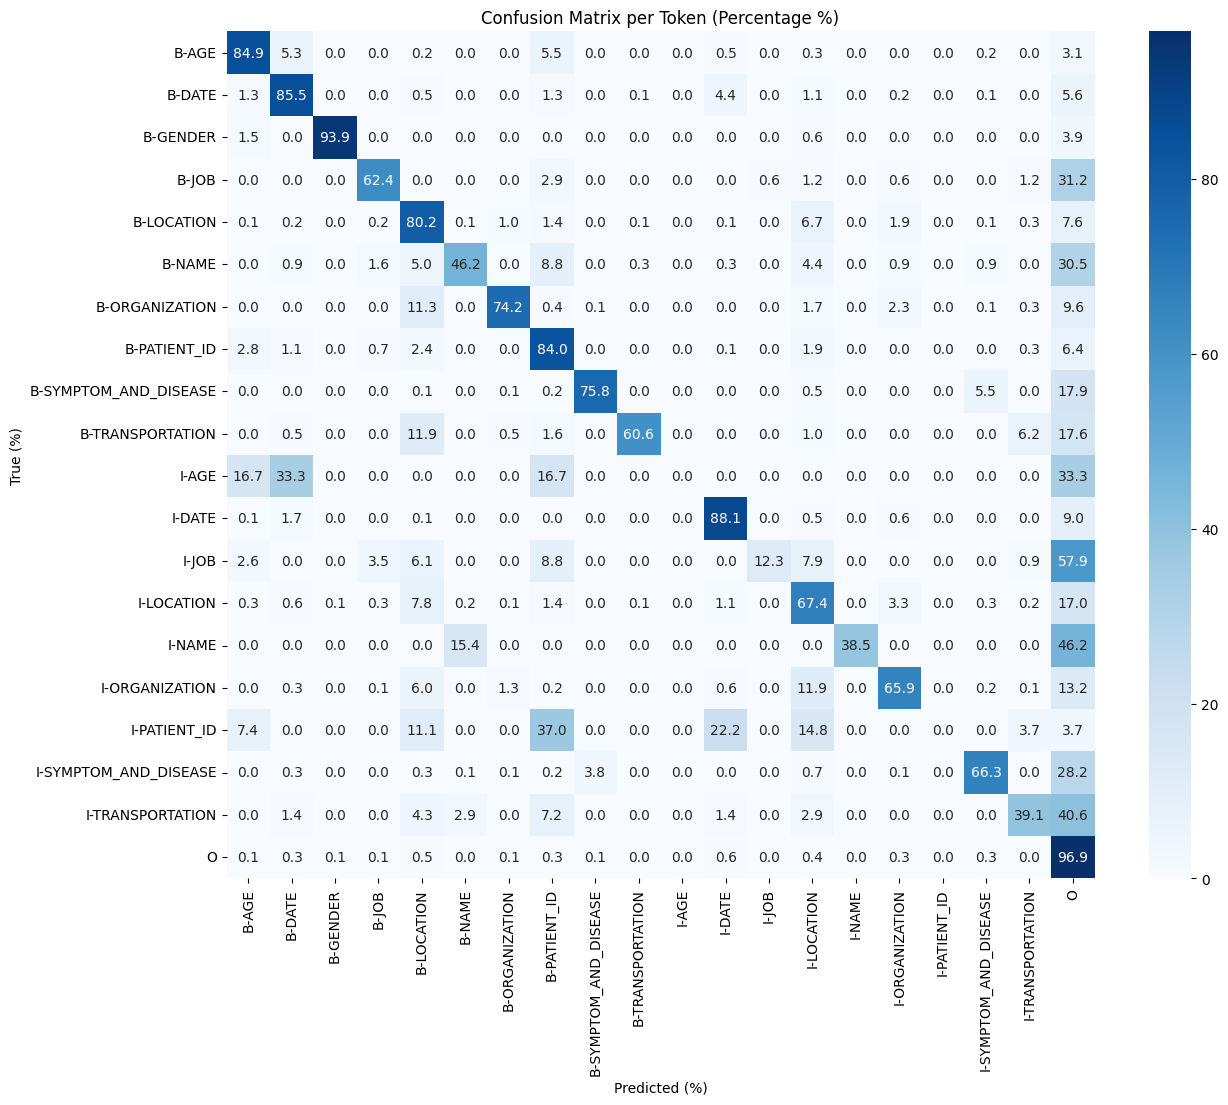

In [60]:
plot_confusion_matrix(true_labels, pred_labels, tag_vocab)

### 3.3. Demo

In [61]:
def predict(model, sentence, word_vocab, tag_vocab, device):
    model.eval()
    tokens = sentence.split()
    input_ids = torch.tensor([word_vocab.encode(tokens)]).to(device)
    
    with torch.no_grad():
        logits = model(input_ids)
        preds = torch.argmax(logits, dim=-1).squeeze(0)
    
    result = []
    for token, pred_id in zip(tokens, preds):
        tag = tag_vocab.itos[pred_id.item()]
        result.append((token, tag))
    
    return result

In [62]:
sentence = "Bệnh nhân số 1234 có lịch trình di chuyển tại Hà Nội ."

print(predict(model, sentence, word_vocab, tag_vocab, device))

[('Bệnh', 'I-LOCATION'), ('nhân', 'O'), ('số', 'O'), ('1234', 'O'), ('có', 'O'), ('lịch', 'O'), ('trình', 'O'), ('di', 'O'), ('chuyển', 'O'), ('tại', 'O'), ('Hà', 'O'), ('Nội', 'O'), ('.', 'O')]
